In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../results/results.csv", sep=None, engine="python")

df["size"] = pd.Categorical(df["size"], categories=["S", "M", "L"], ordered=True)
df["stored_gb"] = df["stored_bytes"] / 1e9

df = df.sort_values(["storage", "size", "file_type"]).reset_index(drop=True)
df

,storage,size,file_type,objects,stored_bytes,upload_seconds,upload_mbps,download_seconds,download_mbps,listing_seconds,query_seconds,stored_gb
0,minio,S,csv,1,240392930,0.381,630.962,0.273,879.416,0.002,3.661,0.240393
1,minio,S,parquet,1,90289418,0.232,389.726,0.081,1117.598,0.002,0.098,0.090289
2,minio,M,csv,1,1201964947,1.378,872.319,1.092,1101.186,0.002,18.190,1.201965
3,minio,M,parquet,1,451444988,0.573,787.265,0.513,879.235,0.002,0.433,0.451445
4,minio,L,csv,1,4807834643,4.550,1056.609,4.595,1046.267,0.004,72.225,4.807835
5,minio,L,parquet,1,1805804060,1.858,971.973,1.659,1088.430,0.002,1.625,1.805804


In [2]:
df[[
    "storage", "size", "file_type", "objects", "stored_gb",
    "upload_mbps", "download_mbps", "listing_seconds", "query_seconds"
]]

,storage,size,file_type,objects,stored_gb,upload_mbps,download_mbps,listing_seconds,query_seconds
0,minio,S,csv,1,0.240393,630.962,879.416,0.002,3.661
1,minio,S,parquet,1,0.090289,389.726,1117.598,0.002,0.098
2,minio,M,csv,1,1.201965,872.319,1101.186,0.002,18.190
3,minio,M,parquet,1,0.451445,787.265,879.235,0.002,0.433
4,minio,L,csv,1,4.807835,1056.609,1046.267,0.004,72.225
5,minio,L,parquet,1,1.805804,971.973,1088.430,0.002,1.625


In [3]:
cmp = df.pivot(index=["storage", "size"], columns="file_type")
cmp.columns = [f"{a}_{b}" for a, b in cmp.columns]
cmp = cmp.reset_index()

cmp["size_reduction_pct"] = 100 * (1 - cmp["stored_bytes_parquet"] / cmp["stored_bytes_csv"])
cmp["query_speedup"] = cmp["query_seconds_csv"] / cmp["query_seconds_parquet"]
cmp["upload_ratio"] = cmp["upload_mbps_parquet"] / cmp["upload_mbps_csv"]
cmp["download_ratio"] = cmp["download_mbps_parquet"] / cmp["download_mbps_csv"]

cmp[[
    "storage", "size",
    "size_reduction_pct",
    "query_speedup",
    "upload_ratio",
    "download_ratio"
]].round(2)

,storage,size,size_reduction_pct,query_speedup,upload_ratio,download_ratio
0,minio,S,62.44,37.36,0.62,1.27
1,minio,M,62.44,42.01,0.90,0.80
2,minio,L,62.44,44.45,0.92,1.04


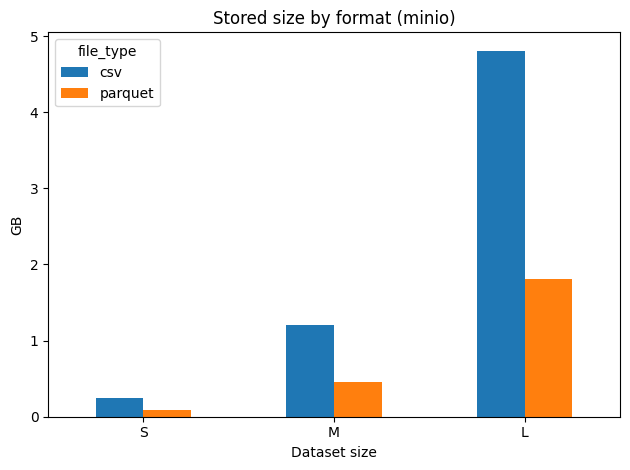

In [4]:
for storage in df["storage"].unique():
    sub = df[df["storage"] == storage]
    pivot = sub.pivot(index="size", columns="file_type", values="stored_gb")
    
    pivot.plot(kind="bar")
    plt.title(f"Stored size by format ({storage})")
    plt.ylabel("GB")
    plt.xlabel("Dataset size")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

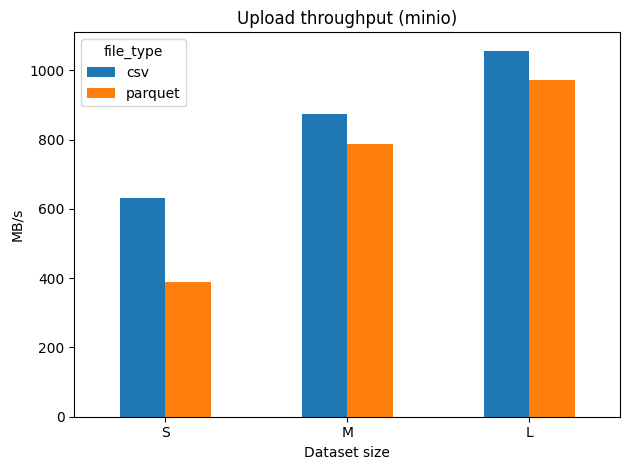

In [5]:
for storage in df["storage"].unique():
    sub = df[df["storage"] == storage]
    pivot = sub.pivot(index="size", columns="file_type", values="upload_mbps")
    
    pivot.plot(kind="bar")
    plt.title(f"Upload throughput ({storage})")
    plt.ylabel("MB/s")
    plt.xlabel("Dataset size")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

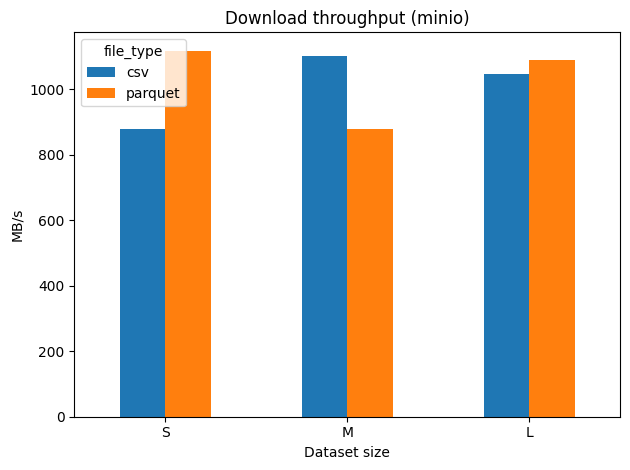

In [6]:
for storage in df["storage"].unique():
    sub = df[df["storage"] == storage]
    pivot = sub.pivot(index="size", columns="file_type", values="download_mbps")
    
    pivot.plot(kind="bar")
    plt.title(f"Download throughput ({storage})")
    plt.ylabel("MB/s")
    plt.xlabel("Dataset size")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

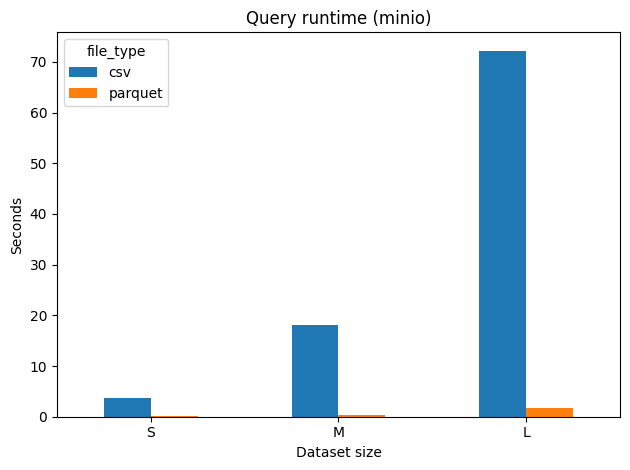

In [7]:
for storage in df["storage"].unique():
    sub = df[df["storage"] == storage]
    pivot = sub.pivot(index="size", columns="file_type", values="query_seconds")
    
    pivot.plot(kind="bar")
    plt.title(f"Query runtime ({storage})")
    plt.ylabel("Seconds")
    plt.xlabel("Dataset size")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

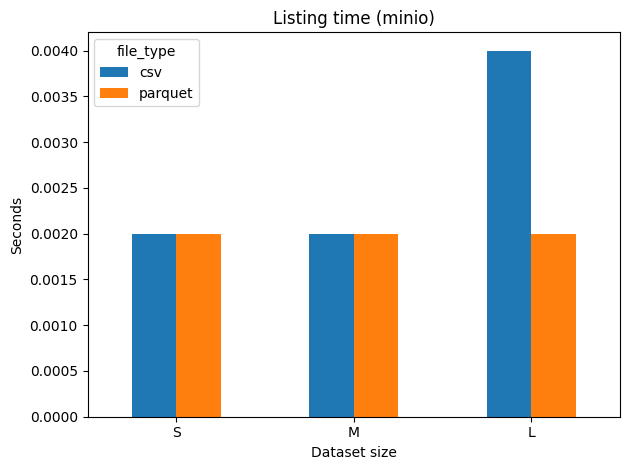

In [8]:
for storage in df["storage"].unique():
    sub = df[df["storage"] == storage]
    pivot = sub.pivot(index="size", columns="file_type", values="listing_seconds")
    
    pivot.plot(kind="bar")
    plt.title(f"Listing time ({storage})")
    plt.ylabel("Seconds")
    plt.xlabel("Dataset size")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [10]:
summary = cmp[[
    "storage", "size",
    "stored_bytes_csv", "stored_bytes_parquet",
    "size_reduction_pct",
    "query_seconds_csv", "query_seconds_parquet",
    "query_speedup"
]].copy()

summary["stored_gb_csv"] = summary["stored_bytes_csv"] / 1e9
summary["stored_gb_parquet"] = summary["stored_bytes_parquet"] / 1e9

summary = summary[[
    "storage", "size",
    "stored_gb_csv", "stored_gb_parquet",
    "size_reduction_pct",
    "query_seconds_csv", "query_seconds_parquet",
    "query_speedup"
]].round(3)

summary

,storage,size,stored_gb_csv,stored_gb_parquet,size_reduction_pct,query_seconds_csv,query_seconds_parquet,query_speedup
0,minio,S,0.240,0.090,62.441,3.661,0.098,37.357
1,minio,M,1.202,0.451,62.441,18.190,0.433,42.009
2,minio,L,4.808,1.806,62.440,72.225,1.625,44.446


In [11]:
for _, row in summary.iterrows():
    print(
        f"{row['storage']} {row['size']}: "
        f"Parquet uses {row['size_reduction_pct']:.1f}% less storage "
        f"and queries are {row['query_speedup']:.1f}x faster than CSV."
    )

minio S: Parquet uses 62.4% less storage and queries are 37.4x faster than CSV.
minio M: Parquet uses 62.4% less storage and queries are 42.0x faster than CSV.
minio L: Parquet uses 62.4% less storage and queries are 44.4x faster than CSV.
